# Customer Segmentation using K_Means Clustering

# Importing Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans


##Collecting the dataset

In [4]:
customer_dataset = pd.read_csv('/content/extracted_data/Mall_Customers.csv')

## Data Preprocessing

In [5]:
#first 5 rows of the dataset
customer_dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
#finding the numbers of rows and columns
customer_dataset.shape

(200, 5)

In [7]:
# finding the null values in the dataset
customer_dataset.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
# checking the detail about of dataset
customer_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
#Checking for some Statistical meansures
customer_dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Feature Selection

### Annual income and Spending Score

In [17]:
# dropping out the unnecessary columns from the dataset
X = customer_dataset.drop(columns=["CustomerID", "Age" , "Gender"], axis=1)

In [18]:
#checkig for updates
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


# Choosing the number of Clusters

### choosing a correct number of clusters -- for different dataset you use different technique -- for this we gonna use Within Cluster Sum of Squares

In [20]:
# Finding WCSS value for different number of clusters

wcss = []

for i in range(1,11):
  kmeans= KMeans(n_clusters=i , init="k-means++" , random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

### Elbow Graph
               --- In the line where are sudden change occur in the normal  
                    trend that strack tell us the number of clusters optimum for the data set like here 2 are the strack after that line
                    remains at the same level so the 5 is the optimum number for clusters for the required data

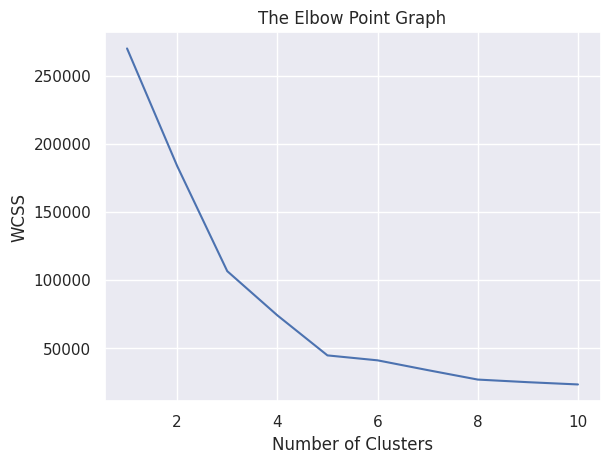

In [21]:
#plot an elbow graph to see which cluster has low value

sns.set()
plt.plot(range(1,11) , wcss)
plt.title("The Elbow Point Graph")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


### The Optimum number of clusters = 5

## Training th K_means Clustering model

In [ ]:
kmeans = KMeans(n_clusters=5 , init = "k-means++" , random_state=42)

In [23]:
#return a label for each data point based on clusters
y = kmeans.fit_predict(X)

In [24]:
print(y)

[6 3 4 3 6 3 4 3 4 3 4 3 4 3 4 3 6 8 6 3 6 8 4 8 4 3 6 8 6 3 4 8 4 3 4 3 4
 8 6 8 6 3 6 8 6 8 8 6 6 6 0 8 0 8 0 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 0 5 2 5 2 5
 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 5 2 1 2 5 2 5 2 1 2 1 2 5 2 1 7 1 7 1 7
 1 7 1 7 1 7 1 7 1 7 9 7 9 7 9]


## Visualizing the Cluster

5 clusters = 0,1,2,3,4

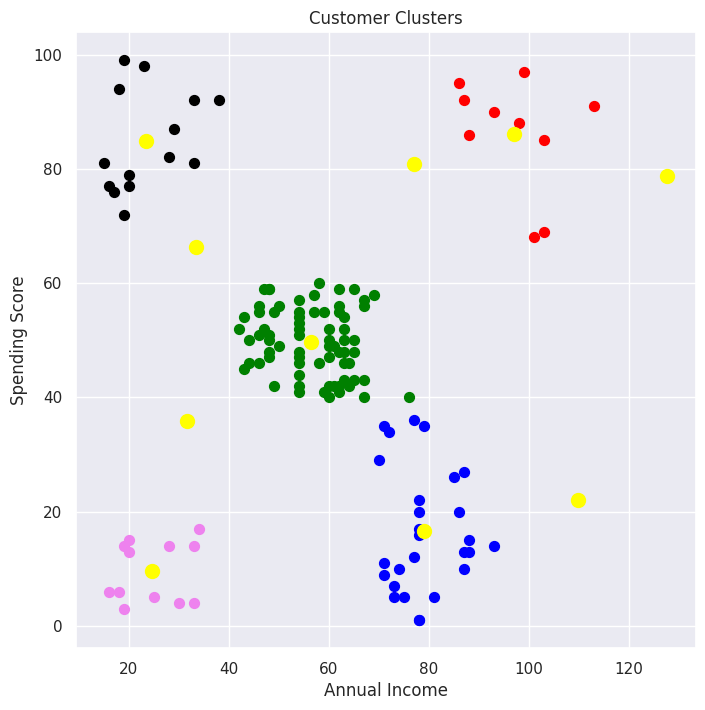

In [27]:
#Plotting all the clusters and tehir Centriod

plt.figure(figsize=(8,8))
plt.scatter(X.iloc[y==0,0] , X.iloc[y==0,1] , s=50 , c='green' , label = 'Cluster=1')
plt.scatter(X.iloc[y==1,0] , X.iloc[y==1,1] , s=50 , c='red' , label = 'Cluster=2')
plt.scatter(X.iloc[y==2,0] , X.iloc[y==2,1] , s=50 , c='blue' , label = 'Cluster=3')
plt.scatter(X.iloc[y==3,0] , X.iloc[y==3,1] , s=50 , c='black' , label = 'Cluster=4')
plt.scatter(X.iloc[y==4,0] , X.iloc[y==4,1] , s=50 , c='violet' , label = 'Cluster=5')

# plot the centroids
plt.scatter(kmeans.cluster_centers_[:,0] , kmeans.cluster_centers_[:,1] , s=100 , c='yellow' , label='Centroids')
plt.title("Customer Clusters")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

### The 1st X[y==0,0]
                  -- 1st 0 show the cluster number like cluster 1
                          -- the clusters are total 5 so the number range form  
                                   0-4 which are 5 clusters
                  -- 2nd 0 here show the X[column = annual income]

### The 2nd X[y==0,0]
                  -- 1st 0 here is also means the cluster number like 1
                   -- the clusters are total 5 so the number range form  
                                   0-4 which are 5 clusters
                  --- 2nd 0 here show the X 2nd [column = spending score]